In [1]:
import json
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from collections import defaultdict
from itertools import combinations
from scipy.optimize import minimize
from pathlib import Path
from tqdm.notebook import tqdm
from pydantic import BaseModel

from qiskit import QuantumCircuit
from qiskit.primitives import (
    BackendSampler,
    BackendSamplerV2,
    BackendEstimator,
    BackendEstimatorV2,
    StatevectorEstimator,
    Estimator,
)
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import EfficientSU2, TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_optimization.applications import Maxcut
from qiskit_optimization.algorithms import MinimumEigenOptimizer, GurobiOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import NELDER_MEAD, COBYLA, L_BFGS_B
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit_aer.primitives import (
    Sampler as AerSampler,
    SamplerV2 as AerSamplerV2,
    Estimator as AerEstimator,
    EstimatorV2 as AerEstimatorV2,
)

from qaoalib import graph_from_name, get_info

from lcc import FullVQE, LCCVQE
from lcc.knapsack import Knapsack

TWO_PI = 2 * np.pi

kp90_dir = Path('data/90')
sc140_dir = Path('data/140')
results_dir = Path('results')

class BPResult(BaseModel):
    ins_name: str
    num_qubits: int
    layers: list[int]
    gradients: list[list[float]]
    means: list[float]
    variances: list[float]

def compute_gradient(f, x, index, h=.001):
    x_plus = x.copy()
    x_plus[index] += h

    x_minus = x.copy()
    x_minus[index] -= h

    return (f(x_plus) - f(x_minus)) / (2 * h)

## Generate Max-cut instances

In [3]:
n = 16
# G = nx.random_regular_graph(5, n, seed=123)
G = nx.fast_gnp_random_graph(n, .9, seed=123)
max_cut = Maxcut(G)
qp = max_cut.to_quadratic_program()
# print(qp.prettyprint())

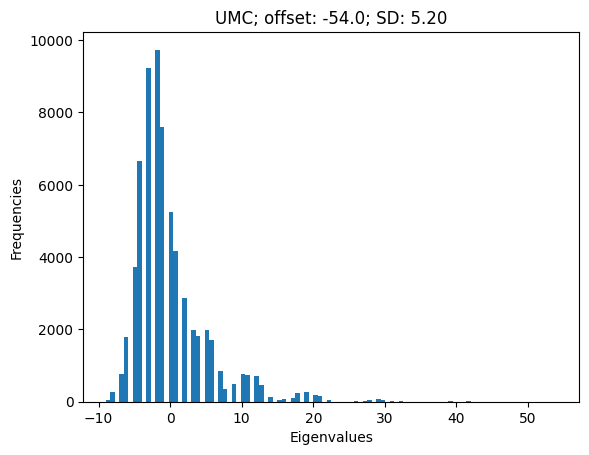

In [4]:
ham, offset = qp.to_ising()
eigs = ham.to_matrix(sparse=True).diagonal(0).real

std = np.std(eigs)

plt.hist(eigs, bins=100)
plt.title(f'UMC; offset: {offset}; SD: {std:.2f}')
plt.xlabel('Eigenvalues')
plt.ylabel('Frequencies')
plt.show()

In [76]:
nodes = [5, 10, 15, 20]
probs = [0.1, 0.3, 0.5, 0.7, 0.9]
stds = defaultdict(list)
num_eigs = defaultdict(list)

for node in nodes:
    for prob in probs:
        G = nx.fast_gnp_random_graph(node, prob, seed=123)
        max_cut = Maxcut(G)
        qp = max_cut.to_quadratic_program()
        ham, _ = qp.to_ising()
        eigs = ham.to_matrix(sparse=True).diagonal(0).real
        stds[node].append(np.std(eigs))
        num_eigs[node].append(len(set(eigs)))


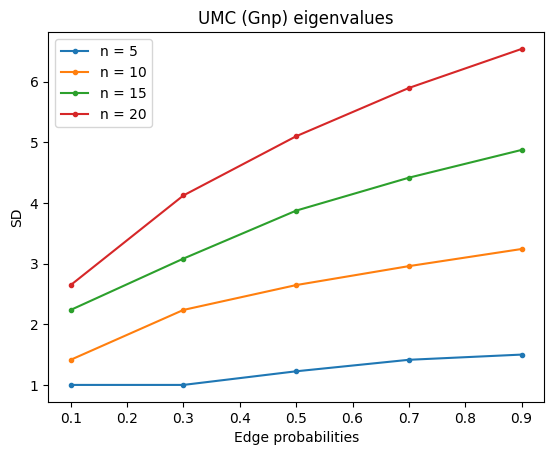

In [114]:
for node, std in stds.items():
    plt.plot(probs, stds[node], marker='.', label=f'n = {node}')

plt.xlabel('Edge probabilities')
plt.ylabel('SD')
plt.title('UMC (Gnp) eigenvalues')
plt.legend()
plt.show()

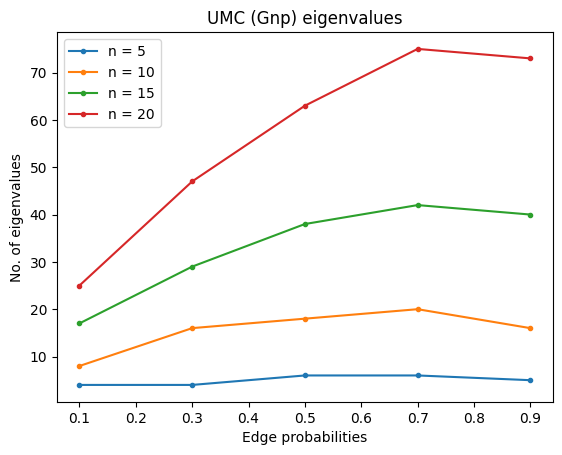

In [113]:
for node, ne in num_eigs.items():
    plt.plot(probs, num_eigs[node], marker='.', label=f'n = {node}')

plt.xlabel('Edge probabilities')
plt.ylabel('No. of eigenvalues')
plt.title('UMC (Gnp) eigenvalues')
plt.legend()
plt.show()

In [ ]:
graph_names = [
    'n10_gnp07_seed0',
    'n10_gnp07_seed1',
    'n10_gnp07_seed2',
    'n10_gnp07_seed3',
    'n10_gnp07_seed4',
    'n10_reg3_seed0',
    'n10_reg3_seed1',
    'n10_reg3_seed2',
    'n10_reg3_seed3',
    'n10_reg3_seed123',    
]

layers = [1, 10, 100, 200, 400]
n_trials = 50
index = 0

for ins_name in (pbar := tqdm(graph_names)):
    pbar.set_description(ins_name)
    G = graph_from_name(ins_name)
    max_cut = Maxcut(G)
    qp = max_cut.to_quadratic_program()

    gradients = []
    all_gradients = []
    means = []
    variances = []

    for layer in layers:
        estimator = StatevectorEstimator()
        optimizer = L_BFGS_B()
        shots = None
        solver = FullVQE(
            qp,
            reps=layer,
            shots=shots,
            estimator=estimator,
            optimizer=optimizer,
        )

        for i in range(n_trials):
            params = solver.generate_random_params()
            gradient = compute_gradient(solver.compute_energy, params, index)
            gradients.append(gradient)

        all_gradients.append(gradients)
        means.append(np.mean(gradients))
        variances.append(np.std(gradients)**2)

    result = BPResult(
        ins_name=ins_name,
        layers=layers,
        gradients=all_gradients,
        means=means,
        variances=variances,
    )
    with open(f'results/{ins_name}.json', 'w') as f:
        json.dump(result.model_dump(), f, indent=4)

## Generate Weighted Max-cut instances

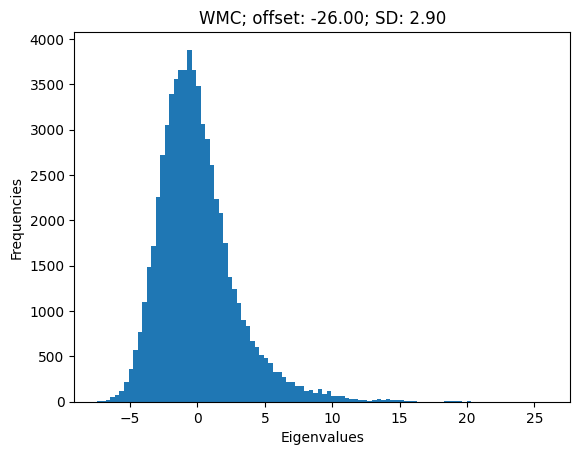

In [5]:
n = 16
# G = nx.random_regular_graph(5, n, seed=123)
G = nx.fast_gnp_random_graph(n, .9, seed=123)

# Add random weights to the edges
for u, v, data in G.edges(data=True):
    data['weight'] = np.random.rand()

max_cut = Maxcut(G)
qp = max_cut.to_quadratic_program()
# print(qp.prettyprint())

ham, offset = qp.to_ising()
eigs = ham.to_matrix(sparse=True).diagonal(0).real

std = np.std(eigs)

plt.hist(eigs, bins=100)
plt.title(f'WMC; offset: {offset:.2f}; SD: {std:.2f}')
plt.xlabel('Eigenvalues')
plt.ylabel('Frequencies')
plt.show()

## Load Knapsack instances

In [6]:
ins_name = 'data_0'
file_path = kp90_dir/f'{ins_name}.json'
knapsack = Knapsack(file_path)
qp = knapsack.quadratic_program
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)

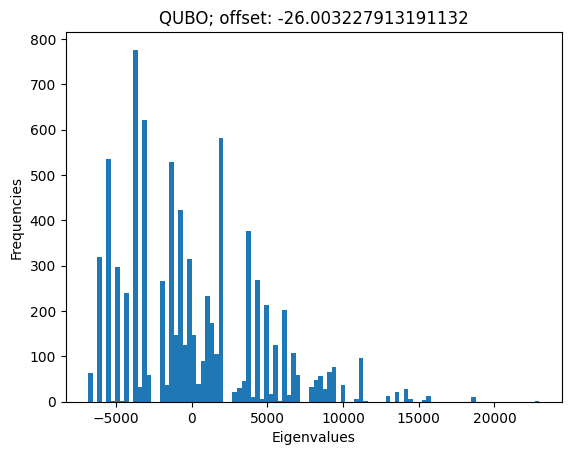

In [7]:
qubo_ham, qubo_offset = qubo.to_ising()
qubo_eigs = qubo_ham.to_matrix(sparse=True).diagonal(0).real

plt.hist(qubo_eigs, bins=100)
plt.title(f'QUBO; offset: {offset}')
plt.xlabel('Eigenvalues')
plt.ylabel('Frequencies')
plt.show()

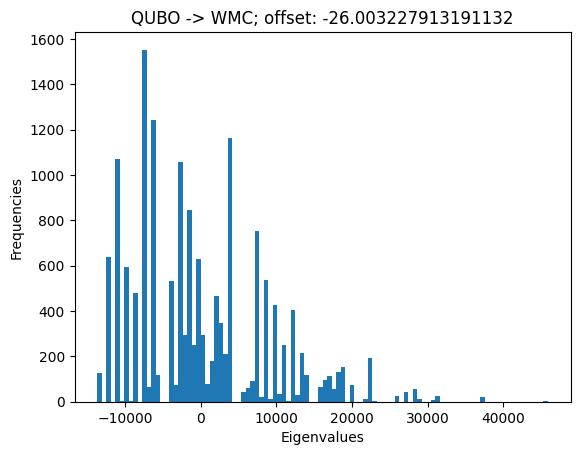

In [8]:
wmc_ham, wmc_offset = knapsack.maxcut_qp.to_ising()
wmc_eigs = wmc_ham.to_matrix(sparse=True).diagonal(0).real

plt.hist(wmc_eigs, bins=100)
plt.title(f'QUBO -> WMC; offset: {offset}')
plt.xlabel('Eigenvalues')
plt.ylabel('Frequencies')
plt.show()

In [90]:
wmc_opt = np.min(wmc_eigs) / 2 + qubo_offset
wmc_opt

-25.0

In [96]:
shifted_eigs = wmc_eigs - np.min(wmc_eigs)
scaled_eigs = shifted_eigs / np.max(shifted_eigs)

In [97]:
np.min(shifted_eigs), np.max(shifted_eigs)

(0.0, 292196.0)

In [98]:
np.min(scaled_eigs), np.max(scaled_eigs)

(0.0, 1.0)

In [105]:
scaled_eigs

array([1.        , 0.14894797, 0.91108023, ..., 0.91108023, 0.14894797,
       1.        ])

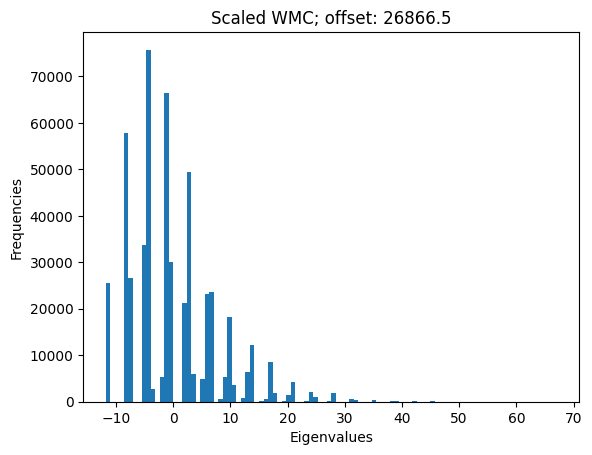

In [109]:
shifted_coeffs = wmc_ham.coeffs - np.min(wmc_eigs)
scaled_coeffs = shifted_coeffs / np.max(shifted_coeffs)

scaled_op = SparsePauliOp(wmc_ham, coeffs=scaled_coeffs)
scaled_eigs = scaled_op.to_matrix(sparse=True).diagonal(0).real

plt.hist(scaled_eigs, bins=100)
plt.title(f'Scaled WMC; offset: {offset}')
plt.xlabel('Eigenvalues')
plt.ylabel('Frequencies')
plt.show()

In [ ]:
pattern = 'data_2*'
layers = [1, 10, 100, 200, 400]
n_trials = 50
index = 0

for fp in (pbar := tqdm(kp90_dir.glob(pattern))):
    with fp.open() as f:
        inp = json.load(f)
    num_qubits = inp['num_bins'] * inp['num_items']
    
    ins_name = fp.stem
    pbar.set_description(ins_name)
    knapsack = Knapsack(fp)
    qp = knapsack.quadratic_program

    gradients = []
    all_gradients = []
    means = []
    variances = []

    for layer in layers:
        estimator = StatevectorEstimator()
        optimizer = L_BFGS_B()
        shots = None
        solver = FullVQE(
            qp,
            reps=layer,
            shots=shots,
            estimator=estimator,
            optimizer=optimizer,
        )

        for i in range(n_trials):
            params = solver.generate_random_params()
            gradient = compute_gradient(solver.compute_energy, params, index)
            gradients.append(gradient)

        all_gradients.append(gradients)
        means.append(np.mean(gradients))
        variances.append(np.std(gradients)**2)

    result = BPResult(
        ins_name=ins_name,
        num_qubits=num_qubits,
        layers=layers,
        gradients=all_gradients,
        means=means,
        variances=variances,
    )
    with open(f'results/{ins_name}.json', 'w') as f:
        json.dump(result.model_dump(), f, indent=4)

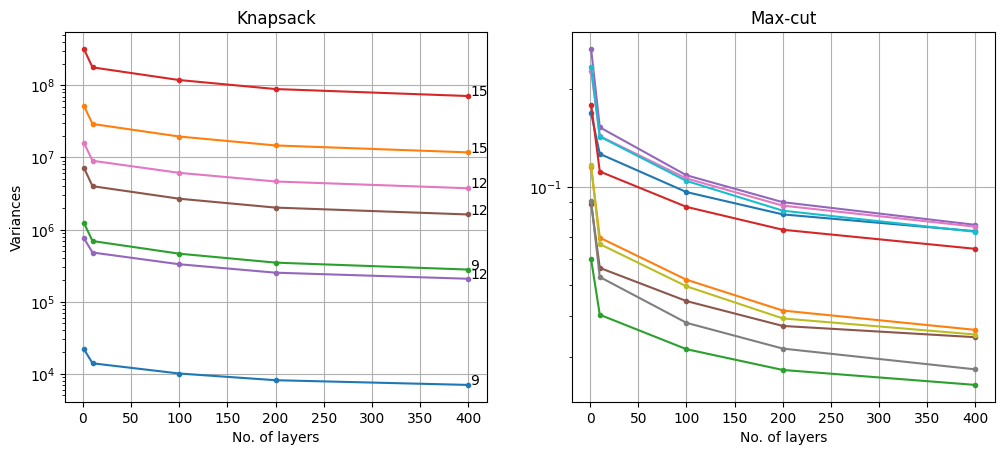

In [116]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

for fp in results_dir.glob('data_*'):
    with fp.open() as f:
        bp_result = BPResult(**json.load(f))
        if len(bp_result.layers) != 5:
            continue

    ax[0].plot(bp_result.layers, bp_result.variances, marker='.')
    ax[0].annotate(bp_result.num_qubits, (bp_result.layers[-1] + 2, bp_result.variances[-1] + 100))


for fp in results_dir.glob('n*'):
    with fp.open() as f:
        bp_result = BPResult(**json.load(f), num_qubits=int(get_info(fp.stem, 'n')))
        # if len(bp_result.layers) != 5:
        #     continue
    
    ax[1].plot(bp_result.layers, bp_result.variances, marker='.')

for a in ax:
    a.grid(True)
    a.set_xlabel('No. of layers')
    a.set_yscale('log')

ax[0].set_ylabel('Variances')
ax[0].set_title('Knapsack')
ax[1].set_title('Max-cut')
plt.show()